In [1]:
import sys, json, os, time, re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import seaborn as sns
from tqdm import tqdm
import random
import zlib
import importlib
from cycler import cycler
from scipy.stats import norm

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.experiment_loader as experiment_loader
from multiomic_transformer.models.model_simplified import MultiomicTransformer
from multiomic_transformer.datasets.dataset_refactor import (
    SimpleScaler,
)

GROUND_TRUTH_DIR = PROJECT_DIR / "data" / "ground_truth_files"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
TRAINING_CACHE_DIR = PROJECT_DIR / "data" / "training_data_cache" 

In [50]:
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

In [2]:
def run_gradient_attribution(
    selected_experiment_dir,
    model,
    test_loader,
    tf_scaler,
    tg_scaler,
    tf_names,
    tg_names,
    device,
    use_amp,
    max_batches: int = None,
    save_every_n_batches: int = 20,
    max_tgs_per_batch = 128,
    chunk_size = 64,
    zero_tf_expr: bool = False,
):

    T_total = len(tf_names)
    G_total = len(tg_names)

    # Creates empty tensors to accumulate gradients across batches. The shape is [TF total, Genes total]
    grad_sum = torch.zeros(T_total, G_total, device=device, dtype=torch.float32)
    grad_count = torch.zeros_like(grad_sum)

    model.to(device).eval()

    iterator = tqdm(
        test_loader,
        desc=f"Gradient attributions",
        unit="batches",
        total=max_batches,
        ncols=100,
    )

    batch_grad_dfs = {}
    for b_idx, batch in enumerate(iterator):
        if max_batches is not None and b_idx >= max_batches:
            break

        atac_wins, tf_tensor, targets, bias, tf_ids, tg_ids, motif_mask = batch
        
        atac_wins = atac_wins.to(device)
        tf_tensor = tf_tensor.to(device)
        bias = bias.to(device) if bias is not None else None
        tf_ids = tf_ids.to(device)
        tg_ids = tg_ids.to(device)
        motif_mask = motif_mask.to(device) if motif_mask is not None else None

        # Shapes
        if tf_tensor.dim() == 2:
            B, T_eval = tf_tensor.shape
            F_dim = 1
        else:
            B, T_eval, F_dim = tf_tensor.shape
            
        if bias is not None:
            if bias.dim() == 2:
                # [G, W] -> [1, G, W]
                bias = bias.unsqueeze(0)

        # Flatten TF IDs over batch for aggregation later
        if tf_ids.dim() == 1:  # [T_eval]
            tf_ids_flat = tf_ids.view(1, T_eval).expand(B, T_eval).reshape(-1)
        else:                  # [B, T_eval]
            tf_ids_flat = tf_ids.reshape(-1)

        G_eval = tg_ids.shape[-1]

        # Assign TGs to this rank and optionally chunk them to control memory.
        if G_eval > max_tgs_per_batch:
            perm = torch.randperm(G_eval, device=device)[:max_tgs_per_batch]
            owned_tg_indices = perm.sort().values
        else:
            owned_tg_indices = torch.arange(G_eval, device=device)

        # ---------- METHOD 1: plain saliency (grad * input) ----------
        total_owned = owned_tg_indices.numel()

        for chunk_start in range(0, total_owned, chunk_size):
            tg_chunk = owned_tg_indices[chunk_start : chunk_start + chunk_size]

            if bias is not None:
                bias_idx = tg_chunk.to(bias.device, non_blocking=True)
                
                if bias.dim() == 2:
                    bias_chunk = bias[bias_idx, :]
                elif bias.dim() == 3:
                    bias_chunk = bias[:, bias_idx, :]
                else:
                    raise ValueError(f"Expected bias to have dim 2 or 3, got shape {bias.shape}")
                
                bias_chunk = bias_chunk.to(device, non_blocking=True)
            else:
                bias_chunk = None

            if tg_ids.dim() == 1:
                tg_ids_chunk = tg_ids[tg_chunk]
            else:
                tg_ids_chunk = tg_ids[:, tg_chunk]

            if zero_tf_expr:
                tf_tensor_chunk = torch.zeros_like(tf_tensor, device=device, requires_grad=True)
            else:
                tf_tensor_chunk = tf_tensor.detach().clone().requires_grad_(True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                tf_scaled = tf_scaler.transform(tf_tensor_chunk, tf_ids) if tf_scaler is not None else tf_tensor_chunk
                preds_s = model(
                    atac_wins,
                    tf_scaled,
                    tf_ids=tf_ids,
                    tg_ids=tg_ids_chunk,
                    bias=bias_chunk,
                )
                if isinstance(preds_s, tuple):
                    preds_s = preds_s[0]

                preds_u = tg_scaler.inverse_transform(preds_s, tg_ids_chunk) if tg_scaler is not None else preds_s
                preds_u = torch.nan_to_num(preds_u.float(), nan=0.0, posinf=1e6, neginf=-1e6)

            grad_output_j = torch.zeros_like(preds_u)

            for offset in range(preds_u.shape[1]):
                grad_output_j.zero_()
                grad_output_j[:, offset] = 1.0

                grads = torch.autograd.grad(
                    outputs=preds_u,
                    inputs=tf_tensor_chunk,
                    grad_outputs=grad_output_j,
                    retain_graph=(offset < preds_u.shape[1] - 1),
                    create_graph=False,
                )[0]

                grad_abs = grads[..., 0].abs() if grads.dim() == 3 else grads.abs()
                grad_flat = grad_abs.reshape(-1)

                tg_global = int(tg_ids_chunk[offset].item()) if tg_ids_chunk.dim() == 1 else int(tg_ids_chunk[0, offset].item())

                grad_sum[:, tg_global].index_add_(0, tf_ids_flat, grad_flat)
                grad_count[:, tg_global].index_add_(0, tf_ids_flat, torch.ones_like(grad_flat))
                
            # cleanup per chunk
            del (
                preds_u,
                preds_s,
                tf_scaled,
                tf_tensor_chunk,
                bias_chunk,
                tg_ids_chunk,
            )
                
        # Inside the loop - periodic saves
        if save_every_n_batches is not None:
            if b_idx % save_every_n_batches == 0:
                
                edge_seen = grad_count > 0
                tf_idx, tg_idx = torch.nonzero(edge_seen, as_tuple=True)

                scores = (grad_sum[tf_idx, tg_idx] / grad_count[tf_idx, tg_idx]).detach().cpu().numpy()

                batch_df_long = pd.DataFrame({
                    "Source": [tf_names[i] for i in tf_idx.cpu().numpy()],
                    "Target": [tg_names[j] for j in tg_idx.cpu().numpy()],
                    "Score": scores,
                })
                 
                batch_grad_dfs[b_idx] = batch_df_long
    
    edge_seen = grad_count > 0
    tf_idx, tg_idx = torch.nonzero(edge_seen, as_tuple=True)

    scores = (grad_sum[tf_idx, tg_idx] / grad_count[tf_idx, tg_idx]).detach().cpu().numpy()

    df_long = pd.DataFrame({
        "Source": [tf_names[i] for i in tf_idx.cpu().numpy()],
        "Target": [tg_names[j] for j in tg_idx.cpu().numpy()],
        "Score": scores,
    })
    
    return df_long, batch_grad_dfs

In [109]:
def format_grn(df):
    def inverse_normal_transform(x):
        r = x.rank(method="average")
        n = len(x)
        p = (r - 0.5) / n          # avoids 0 and 1
        return norm.ppf(p)
    
    # Apply rank-based inverse normal transform (INT)
    df["Score"] = df.groupby("Source")["Score"].transform(inverse_normal_transform)
    
    df = df.dropna()
    
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()
    
    return df

def quick_pooled_auroc(exp, labeled_df):
    balanced = exp._balance_pos_neg(labeled_df, random_state=42)
    y = balanced["_in_gt"].astype(int).to_numpy()
    s = balanced["Score"].to_numpy()
    
    auroc = roc_auc_score(y, s)
    
    return auroc

def quick_per_tf_auroc(exp, labeled_df):
    per_tf_auroc = []
    
    for tf, group in labeled_df.groupby("Source"):
        balanced = exp._balance_pos_neg(group, random_state=42)
        y = balanced["_in_gt"].astype(int).to_numpy()
        s = balanced["Score"].to_numpy()
        
        if len(np.unique(y)) > 1:
            auroc = roc_auc_score(y, s)
            per_tf_auroc.append(auroc)
        else:
            per_tf_auroc.append(np.nan)  # or some default value for TFs with only pos or neg examples
    
    median_per_tf_auroc = np.nanmedian(per_tf_auroc)
    
    return median_per_tf_auroc

def plot_gpu_memory(gpu_mem_df):
    df = gpu_mem_df.copy()
    df = df.groupby("step")[[
        "allocated_mb", 
        "reserved_mb",
        "free_mb",
        "total_memory_mb",
        "allocated_pct_total", 
        "reserved_pct_total",
        "free_pct_total",
        ]].mean().reset_index()
    
    df = df.iloc[5:]
    
    plt.figure(figsize=(4,3))
    plt.plot(df["step"], df["allocated_mb"], color=color_palette["blue_light"], label="Allocated")
    plt.plot(df["step"], df["reserved_mb"], linestyle="--", color=color_palette["grey_light"], label="Reserved")

    total_mem = df["total_memory_mb"].iloc[0]
    plt.hlines(
        total_mem,
        df["step"].min(),
        df["step"].max(),
        linestyles="dashed",
        label="Total",
        color=color_palette["grey_dark"],
    )

    plt.xlabel("Training Step")
    plt.ylabel("Memory (MB)")
    plt.title(f"GPU Memory Usage")
    plt.legend(
        bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.,
        title="Memory Type"
    )
    plt.show()
    
def plot_training_time_by_step(df_full):
    df = df_full.copy()
    df = df.groupby("step")[["loader_s", "transfer_s", "forward_s", "backward_s"]].mean().reset_index()
    df["loader_s"] = df["loader_s"].rolling(window=10, min_periods=1).mean()
    df["transfer_s"] = df["transfer_s"].rolling(window=10, min_periods=1).mean()
    df["forward_s"] = df["forward_s"].rolling(window=10, min_periods=1).mean()
    df["backward_s"] = df["backward_s"].rolling(window=10, min_periods=1).mean()
    
    df = df.iloc[10:].iloc[:-20]

    plt.figure(figsize=(6, 4))
    plt.plot(df["step"], df["loader_s"], label="Data Loading")
    plt.plot(df["step"], df["transfer_s"], label="Data Transfer")
    plt.plot(df["step"], df["forward_s"], label="Forward Pass")
    plt.plot(df["step"], df["backward_s"], label="Backward Pass")
    plt.xlabel("Training Step")
    plt.ylabel("Time (s)")
    plt.title(f"Training Time by Step")
    plt.legend(
            bbox_to_anchor=(1.05, 0.5), loc='center left',
            title="Training Step", borderaxespad=0.
    )
    plt.show()

In [55]:
importlib.reload(experiment_loader)

exp = experiment_loader.ExperimentLoader(
    experiment_dir = "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/",
    experiment_name="mESC_muon_preprocessing_simplified_pooling",
    model_num=11,
)

metacells = exp.model_training_params["metacells"]
windows = exp.model_training_params["windows"]
genes = exp.model_training_params["genes"]
tfs = exp.model_training_params["tfs"]
print(f"Metacells: {metacells}")
print(f"Windows: {windows}")
print(f"Genes: {genes}")
print(f"TFs: {tfs}")

Metacells: 2792
Windows: 127778
Genes: 17110
TFs: 1351


In [57]:
batch_size=128

print("Creating dataset...")
dataset = exp.create_multichrom_dataset(
    max_cached=100,
)

print("Creating dataloaders...")
train_loader, val_loader, test_loader = exp.prepare_dataloader(
    dataset,
    batch_size=batch_size,
    world_size=1,
    rank=0,
    num_workers=8,
    pin_memory=True,
)

print("Creating and fitting scalers...")
scalers = exp.create_scalers(
    dataset=dataset,
    dataloader=train_loader,
)

Creating dataset...
Creating dataloaders...
Creating and fitting scalers...


In [ ]:
first_batch = next(iter(train_loader))
atac_wins, tf_tensor, tg_tensor, bias, tf_ids, tg_ids, motif_mask = first_batch
print("Shapes of first batch:")
print(f"atac_wins: {atac_wins.shape}")
print(f"tf_tensor: {tf_tensor.shape}")
print(f"tg_tensor: {tg_tensor.shape}")
print(f"bias: {bias.shape if bias is not None else None}")
print(f"tf_ids: {tf_ids.shape}")
print(f"tg_ids: {tg_ids.shape}")

In [113]:
epochs = 5
bias_scale = 0.0
num_layers = 3
num_heads = 4
d_model = 128
d_ff = d_model*4
kernel_sizes = [64]

max_grad_attrib_batches = 25

training_time_size_dict = {}

gpu_mem_dfs = []
batch_profile_dfs = []
auroc_df_list = []

ground_truth = exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv")

for kernel_size in kernel_sizes:
    print(f"\n=== Running experiment with kernel_size={kernel_size} ===")
    
    # ----- Create a new model -----
    model = exp.create_new_model(
        dataset=dataset,
        bias_scale=bias_scale,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        window_pool_size=kernel_size,
    )

    # ----- Train the model and log GPU memory and batch times -----
    train_time_start = time.time()
    model = exp.train_timed(
        model,
        train_loader,
        val_loader,
        num_epochs=epochs,
        validate_every=2,
        max_batches=None,
        monitor_gpu_memory=True,
        profile_batches=True,
    )
    train_time_end = time.time()
    
    # # ----- Gradient Attribution on the Trained Model -----
    # selected_experiment_dir = exp.model_training_dir / "grn_results_by_checkpoint" / "testing_bias_scale"
    # start_time = time.time()
    # grad_attr_df, grad_batch_dfs = run_gradient_attribution(
    #     selected_experiment_dir=exp.model_training_dir,
    #     model=model,
    #     test_loader=test_loader,
    #     tf_scaler=scalers["tf_scaler"],
    #     tg_scaler=scalers["tg_scaler"],
    #     tf_names = exp.tf_names,
    #     tg_names = exp.tg_names,
    #     use_amp=False,
    #     max_batches=max_grad_attrib_batches,
    #     device=exp.device,
    #     save_every_n_batches=1,
    #     max_tgs_per_batch=128,
    # )

    # end_time = time.time()
    # print(f"  - Gradient attribution finished {max_grad_attrib_batches} batches in {end_time - start_time:.2f} seconds.")

    # # ----- Calculate the AUROC -----
    # ground_truth_df, gt_lookup = ground_truth

    # df = format_grn(grad_attr_df)[["Source", "Target", "Score"]].copy()
    
    # labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, "ChIP-Atlas macrophage")

    # y_all = labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
    # s_all = labeled_df["Score"].to_numpy()
    
    # pooled_auroc = quick_pooled_auroc(exp, labeled_df)
    # per_tf_median_auroc = quick_per_tf_auroc(exp, labeled_df)
    
    # auroc_df = pd.DataFrame({
    #     "kernel_size": kernel_size,
    #     "pooled_auroc": pooled_auroc,
    #     "per_tf_median_auroc": per_tf_median_auroc,
    # }, index=[0])
    
    # auroc_df_list.append(auroc_df)
    training_time = train_time_end - train_time_start
    avg_time_per_epoch = training_time / epochs

    training_time_size_dict[kernel_size] = {
        "total": training_time,
        "avg_per_epoch": avg_time_per_epoch
    }

    exp.gpu_mem_log_df["kernel_size"] = kernel_size
    exp.batch_profile_df["kernel_size"] = kernel_size

    gpu_mem_dfs.append(exp.gpu_mem_log_df.copy())
    batch_profile_dfs.append(exp.batch_profile_df.copy())

for kernel_size, times in training_time_size_dict.items():
    print(
        f"Kernel Size: {kernel_size} | "
        f"Total Time: {times['total']:.1f}s, Avg Time/Epoch: {times['avg_per_epoch']:.1f}s"
    )

gpu_mem_df_all = pd.concat(gpu_mem_dfs, ignore_index=True)
batch_profile_df_all = pd.concat(batch_profile_dfs, ignore_index=True)
# auroc_df_all = pd.concat(auroc_df_list, ignore_index=True)


=== Running experiment with kernel_size=64 ===


Epoch 1/5 | Train Loss: 0.0951 | LR: 1.00e-04 | Time: 14.4s


Epoch 2/5 | Train Loss: 0.0793 | Val MSE: 0.0735 | R2 (Unscaled): -0.063 | R2 (Scaled): -0.063 | LR: 1.00e-04 | Time: 14.3s


Epoch 3/5 | Train Loss: 0.0753 | LR: 1.00e-04 | Time: 14.3s


Epoch 4/5 | Train Loss: 0.0710 | Val MSE: 0.0693 | R2 (Unscaled): -0.001 | R2 (Scaled): -0.001 | LR: 1.00e-04 | Time: 14.3s


Epoch 5/5 | Train Loss: 0.0688 | LR: 1.00e-04 | Time: 14.4s
Kernel Size: 64 | Total Time: 74.1s, Avg Time/Epoch: 14.8s


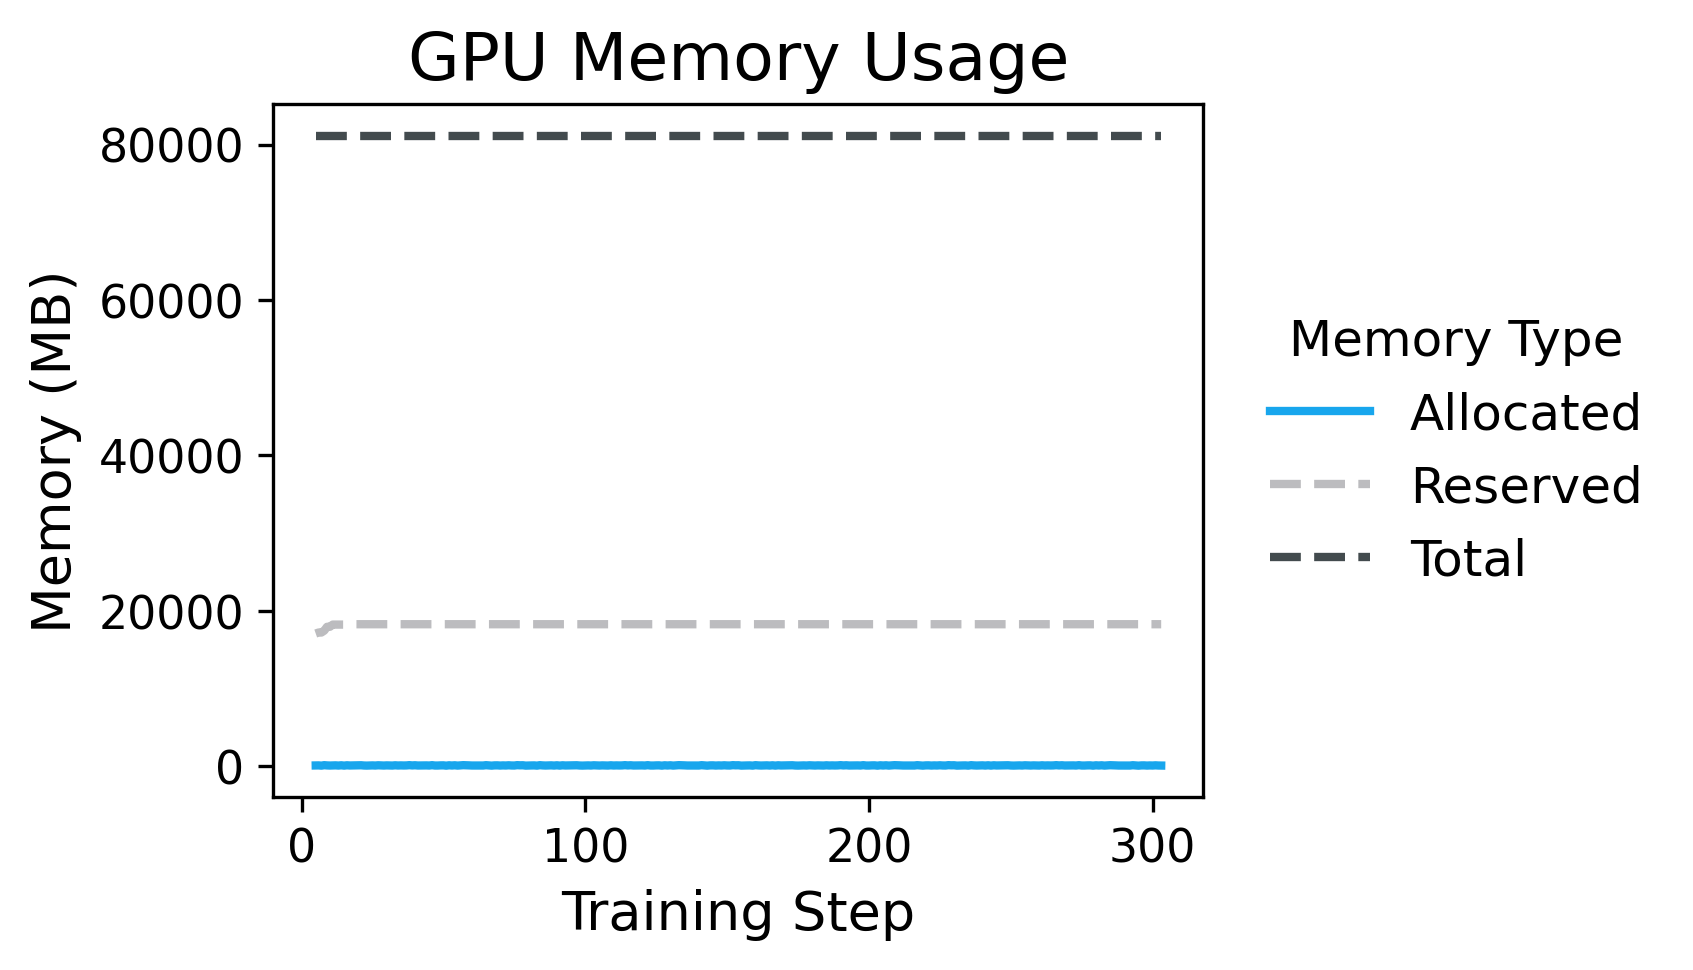

In [110]:
plot_gpu_memory(gpu_mem_df_all)

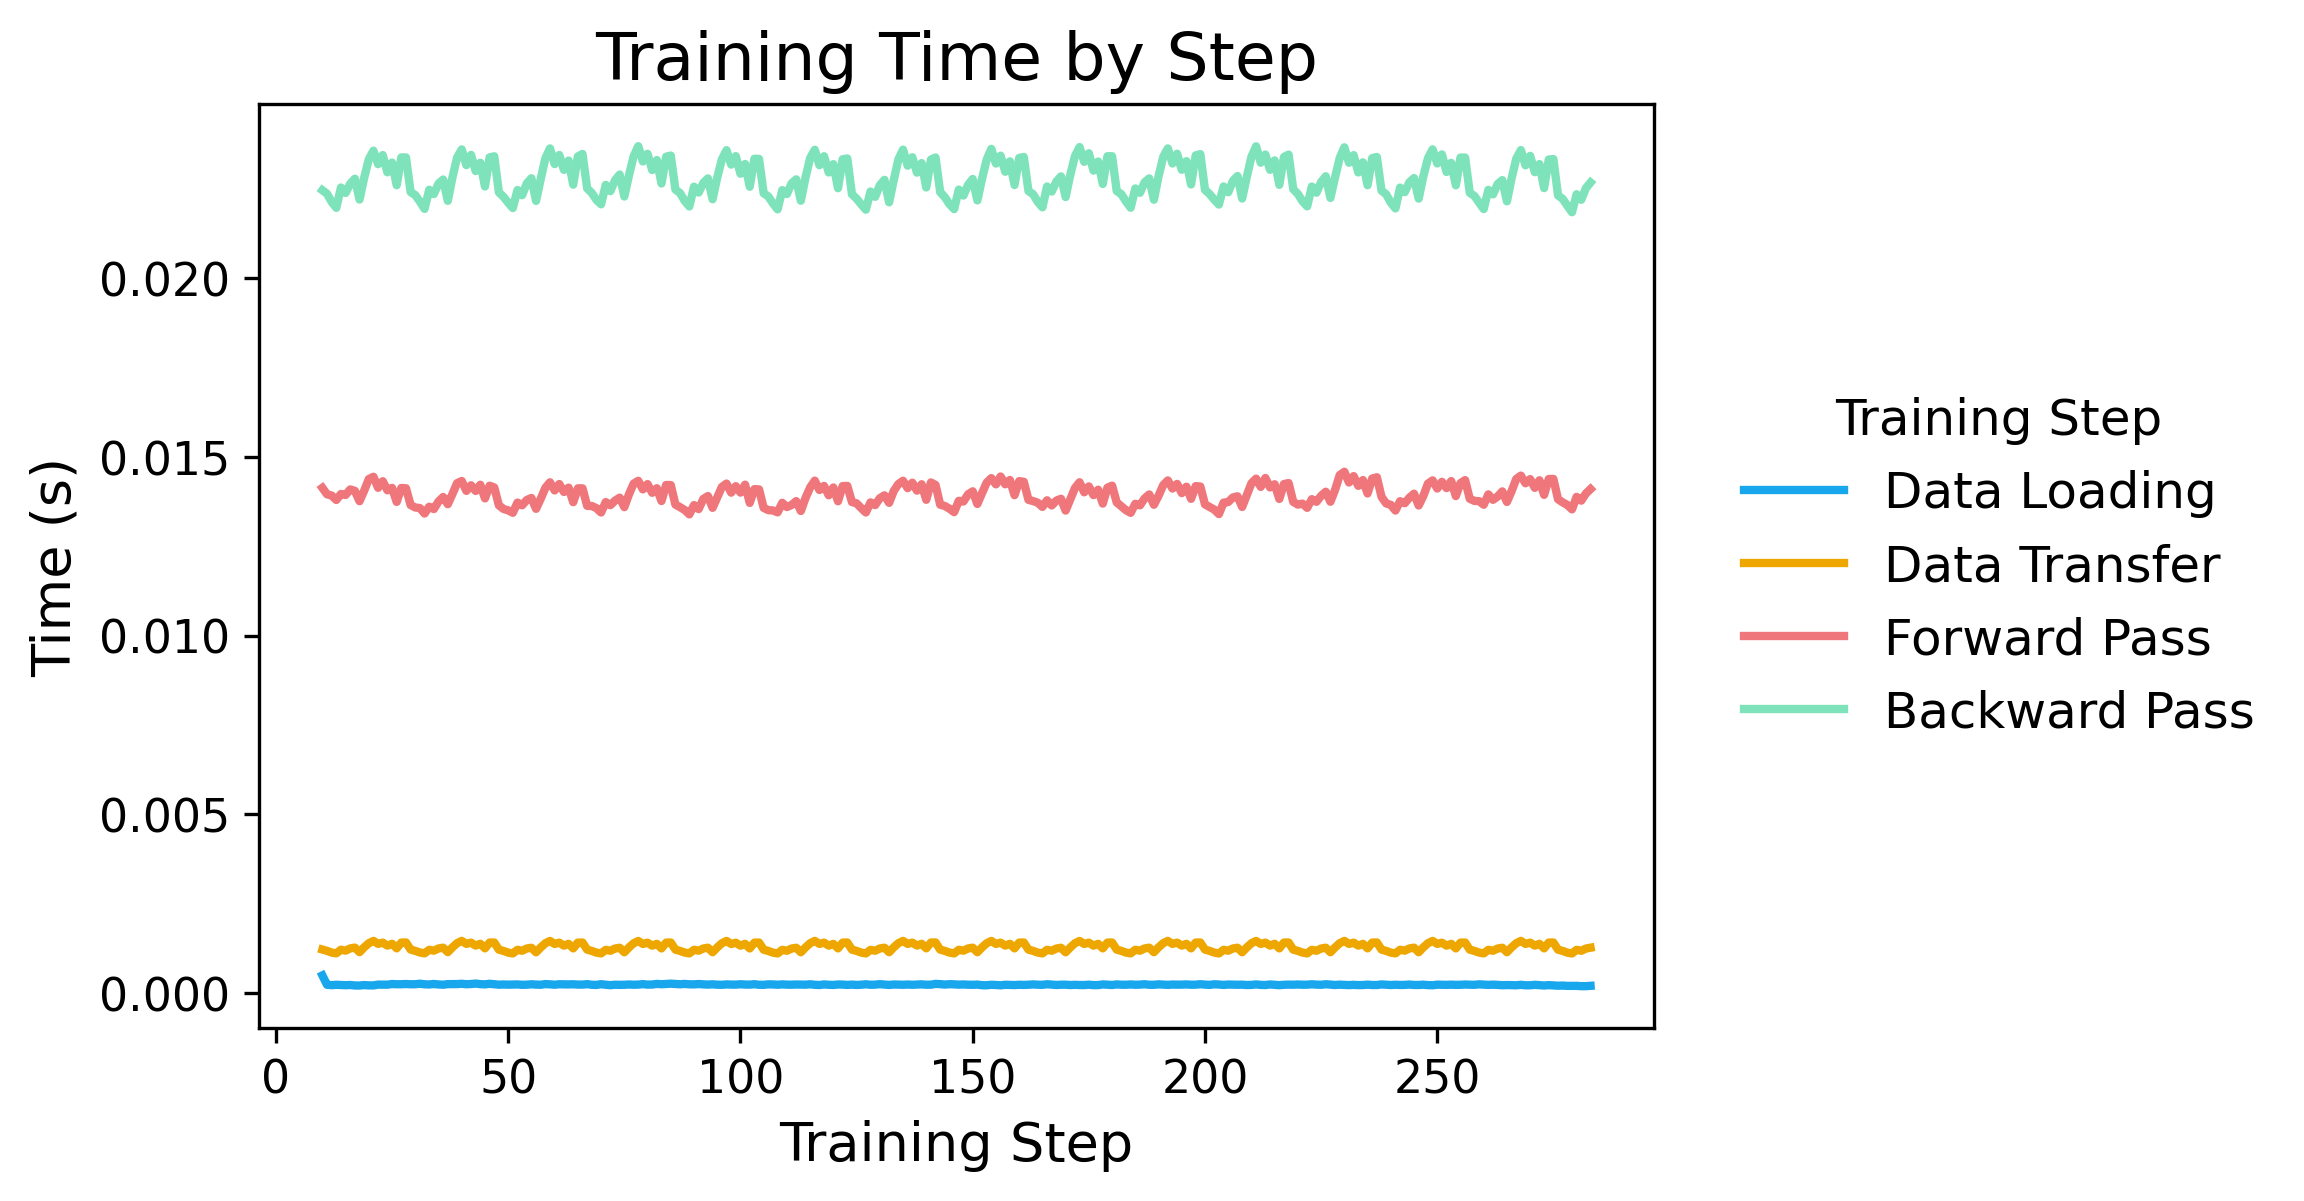

In [112]:
plot_training_time_by_step(batch_profile_df_all)

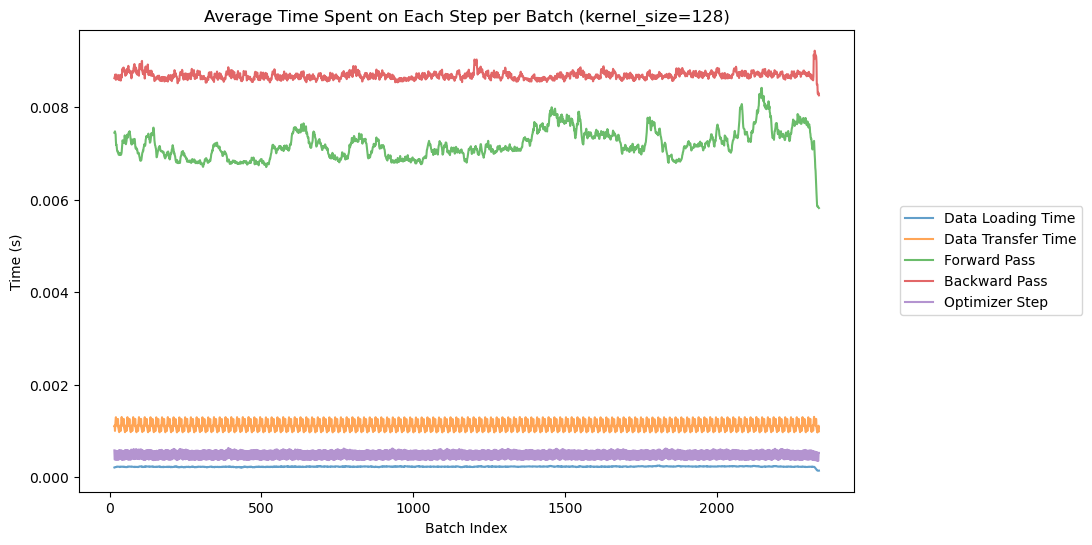

In [40]:
plt.figure(figsize=(10, 6))
batch_by_step = batch_by_step.iloc[11:]
plt.plot(batch_by_step["step"], batch_by_step["loader_s"], label="Data Loading Time", alpha=0.7)
plt.plot(batch_by_step["step"], batch_by_step["transfer_s"], label="Data Transfer Time", alpha=0.7)
plt.plot(batch_by_step["step"], batch_by_step["forward_s"], label="Forward Pass", alpha=0.7)
plt.plot(batch_by_step["step"], batch_by_step["backward_s"], label="Backward Pass", alpha=0.7)
plt.plot(batch_by_step["step"], batch_by_step["optim_s"], label="Optimizer Step", alpha=0.7)
plt.xlabel("Batch Index")
plt.ylabel("Time (s)")
plt.title("Average Time Spent on Each Step per Batch (kernel_size=128)")
plt.legend(
    bbox_to_anchor=(1.05, 0.5), loc='center left'
)
plt.show()

In [104]:
@torch.no_grad()
def find_all_zero_tgs_from_dataset(multichrom_dataset):
    G_expected = len(multichrom_dataset.tg_name2id)

    tg_seen = torch.zeros(G_expected, dtype=torch.bool)
    tg_nonzero_seen = torch.zeros(G_expected, dtype=torch.bool)

    for chrom in multichrom_dataset.chrom_ids:
        ds = multichrom_dataset._load_chrom(chrom)

        tg_ids = ds.tg_ids.long().cpu()                  # local rows -> global ids
        tg_mat = ds.tg_tensor_all                        # [G_eval, num_cells]

        tg_seen[tg_ids] = True
        tg_nonzero_seen[tg_ids] |= (tg_mat != 0).any(dim=1).cpu()

    all_zero_present_ids = (tg_seen & ~tg_nonzero_seen).nonzero(as_tuple=True)[0]
    never_present_ids = (~tg_seen).nonzero(as_tuple=True)[0]

    tg_names = multichrom_dataset.tg_names
    return {
        "all_zero_present_ids": all_zero_present_ids,
        "all_zero_present_names": [tg_names[i] for i in all_zero_present_ids.tolist()],
        "never_present_ids": never_present_ids,
        "never_present_names": [tg_names[i] for i in never_present_ids.tolist()],
    }
    
zero_tg_info = find_all_zero_tgs_from_dataset(dataset)
print("Number of TGs that are all-zero but present in some batch:", len(zero_tg_info["all_zero_present_ids"]))
print("First 20 all-zero-but-present TGs:", zero_tg_info["all_zero_present_names"][:20])
print("Number of TGs that are never present in any batch:", len(zero_tg_info["never_present_ids"]))
print("First 20 never-present TGs:", zero_tg_info["never_present_names"][:20])

Number of TGs that are all-zero but present in some batch: 88
First 20 all-zero-but-present TGs: ['1500012K07RIK', '1700029N11RIK', '1700042G15RIK', '1700120G07RIK', '2210404E10RIK', '2310034O05RIK', '4930442L01RIK', '4930486F22RIK', '4930540M03RIK', '5330439B14RIK', '9230020A06RIK', 'A330070K13RIK', 'ACTC1DT', 'AU021063', 'BC048679', 'BRCC3DC', 'C330022C24RIK', 'C730036E19RIK', 'CBLIF', 'CD5L']
Number of TGs that are never present in any batch: 659
First 20 never-present TGs: ['1700013H16RIK', '1700020N15RIK', '1700111N16RIK', '1700121L16RIK', '1810030O07RIK', '2010204K13RIK', '2010308F09RIK', '2810403D21RIK', '3010001F23RIK', '3632454L22RIK', '3830403N18RIK', '4930453H23RIK', '4930515L19RIK', '4933407K13RIK', '4933409K07RIK', '4933416I08RIK', '4933428M09RIK', '5330434G04RIK', '5530601H04RIK', '5730405O15RIK']


In [ ]:
def get_chrom_from_idx(dataset, idx):
    offsets = dataset._offsets
    chrom_ids = dataset.chrom_ids
    
    # find which interval idx belongs to
    for i in range(len(offsets)):
        start = offsets[i]
        end = offsets[i + 1] if i + 1 < len(offsets) else len(dataset)
        if start <= idx < end:
            return chrom_ids[i]
    return None

test_bs = test_loader.batch_sampler

for i, batch_indices in enumerate(test_bs):
    chrom = get_chrom_from_idx(dataset, batch_indices[0])
    print(f"Batch {i}: {chrom}")
    
    if i > 20:
        break

In [32]:
selected_experiment_dir = exp.model_training_dir / "grn_results_by_checkpoint" / "testing_bias_scale"

max_batches = 50

start_time = time.time()
grad_attr_df, grad_batch_dfs = run_gradient_attribution(
    selected_experiment_dir=exp.model_training_dir,
    model=model,
    test_loader=test_loader,
    tf_scaler=scalers["tf_scaler"],
    tg_scaler=scalers["tg_scaler"],
    tf_names = exp.tf_names,
    tg_names = exp.tg_names,
    use_amp=False,
    max_batches=max_batches,
    device=exp.device,
    save_every_n_batches=1,
    max_tgs_per_batch=128,
)

end_time = time.time()
print(f"  - Gradient attribution finished {max_batches} batches in {end_time - start_time:.2f} seconds.")

Gradient attributions:   0%|                                            | 0/50 [00:00<?, ?batches/s]


IndexError: too many indices for tensor of dimension 2

In [11]:
running_batch_metrics = []

ground_truth = exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv")
ground_truth_df, gt_lookup = ground_truth
for b_idx, batch_df in tqdm(
    sorted(grad_batch_dfs.items()),
    total=len(grad_batch_dfs),
    ncols=100,
    desc="Evaluating batches"
):
    df = format_grn(batch_df)[["Source", "Target", "Score"]].copy()
    
    labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, "ChIP-Atlas macrophage")

    y_all = labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
    s_all = labeled_df["Score"].to_numpy()
    
    pooled_auroc = quick_pooled_auroc(exp, labeled_df)
    per_tf_median_auroc = quick_per_tf_auroc(exp, labeled_df)

    running_batch_metrics.append({
        "batch_num": b_idx,
        "pooled_auroc": pooled_auroc,
        "per_tf_median_auroc": per_tf_median_auroc,

    })

auroc_by_num_batches = pd.DataFrame(running_batch_metrics).sort_values("batch_num")

Evaluating batches: 100%|███████████████████████████████████████████| 50/50 [03:15<00:00,  3.91s/it]


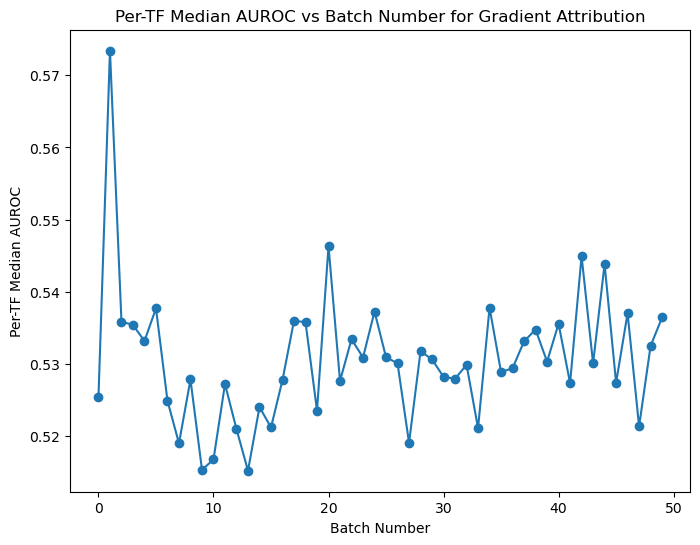

In [12]:
auroc_by_batch_num = auroc_by_num_batches.groupby("batch_num")["per_tf_median_auroc"].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.plot(auroc_by_batch_num["batch_num"], auroc_by_batch_num["per_tf_median_auroc"], marker="o")
plt.xlabel("Batch Number")
plt.ylabel("Per-TF Median AUROC")
plt.title("Per-TF Median AUROC vs Batch Number for Gradient Attribution")
plt.show()

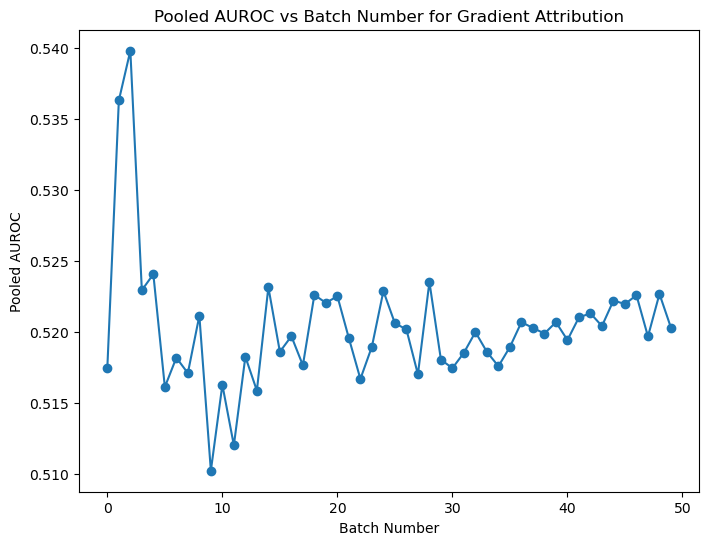

In [13]:
auroc_by_batch_num = auroc_by_num_batches.groupby("batch_num")["pooled_auroc"].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.plot(auroc_by_batch_num["batch_num"], auroc_by_batch_num["pooled_auroc"], marker="o")
plt.xlabel("Batch Number")
plt.ylabel("Pooled AUROC")
plt.title("Pooled AUROC vs Batch Number for Gradient Attribution")
plt.show()

Run a test to see if the bias scale affects the AUROC

In [ ]:
ground_truth = exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv")
ground_truth_df, gt_lookup = ground_truth

d_model = 128
num_heads = 4
num_layers = 3
d_ff = 512
dropout = 0.1
tf_vocab_size = len(exp.tf_names)
tg_vocab_size = len(exp.tg_names)
use_dist_bias = True
bias_scale = 0.0

train_loader, val_loader, test_loader = exp.prepare_dataloader(
    dataset,
    batch_size=16,
    world_size=1,
    rank=0,
)

T = int(dataset.tf_ids.numel())
G = int(dataset.tg_ids.numel())

tf_s, tg_s = fit_simple_scalers(
    train_loader,
    T_expected=T,
    G_expected=G,
    device_for_reduce=exp.device,
    use_ddp_reduce=False,
)

tf_scaler = SimpleScaler(tf_s.mean.to(exp.device), tf_s.std.to(exp.device))
tg_scaler = SimpleScaler(tg_s.mean.to(exp.device), tg_s.std.to(exp.device))

bias_scale_results = []
import time
start_time = time.time()

for bias_scale in [0.0, 1.0, 2.0, 4.0, 8.0]:
    print(f"\nRunning gradient attribution with bias scale = {bias_scale}")
    # Create a fresh model 
    model = MultiomicTransformer(
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        tf_vocab_size=tf_vocab_size,
        tg_vocab_size=tg_vocab_size,
        use_bias=use_dist_bias,
        bias_scale=bias_scale,
    ).to(exp.device)
    
    
    # Run gradient attribution and evaluation for the untrained model with this bias scale
    selected_experiment_dir = exp.model_training_dir / "grn_results_by_checkpoint" / "untrained_model"
    selected_experiment_dir.mkdir(parents=True, exist_ok=True)

    max_batches = 50

    start_time = time.time()
    grad_attr_df, grad_batch_dfs = run_gradient_attribution(
        selected_experiment_dir=exp.model_training_dir,
        model=model,
        test_loader=dataloaders["test"],
        tf_scaler=scalers["tf_scaler"],
        tg_scaler=scalers["tg_scaler"],
        tf_names = exp.tf_names,
        tg_names = exp.tg_names,
        use_amp=False,
        max_batches=max_batches,
        device=exp.device,
        save_every_n_batches=1,
        max_tgs_per_batch=128,
    )

    end_time = time.time()
    print(f"  - Gradient attribution finished {max_batches} batches in {end_time - start_time:.2f} seconds.")
    
    running_batch_metrics = []

    ground_truth = exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv")
    ground_truth_df, gt_lookup = ground_truth
    for b_idx, batch_df in tqdm(
        sorted(grad_batch_dfs.items()),
        total=len(grad_batch_dfs),
        ncols=100,
        desc="Evaluating batches"
    ):
        df = format_grn(batch_df)[["Source", "Target", "Score"]].copy()
        
        labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, "ChIP-Atlas macrophage")

        y_all = labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
        s_all = labeled_df["Score"].to_numpy()
        
        pooled_auroc = quick_pooled_auroc(exp, labeled_df)
        per_tf_median_auroc = quick_per_tf_auroc(exp, labeled_df)

        running_batch_metrics.append({
            "batch_num": b_idx,
            "pooled_auroc": pooled_auroc,
            "per_tf_median_auroc": per_tf_median_auroc,

        })

    auroc_by_num_batches = pd.DataFrame(running_batch_metrics).sort_values("batch_num")
    
    auroc_by_num_batches["bias_scale"] = bias_scale
    
    bias_scale_results.append(auroc_by_num_batches)

final_auroc_df = pd.concat(bias_scale_results, ignore_index=True)
final_auroc_df.head()

finished_time = time.time()
print(f"Finished testing all bias scales in {finished_time - start_time:.2f} seconds.")


Running gradient attribution with bias scale = 0.0


Gradient attributions: 100%|███████████████████████████████████| 50/50 [00:45<00:00,  1.10batches/s]


  - Gradient attribution finished 50 batches in 46.32 seconds.


Evaluating batches: 100%|███████████████████████████████████████████| 50/50 [01:33<00:00,  1.87s/it]



Running gradient attribution with bias scale = 1.0


...


Running gradient attribution with bias scale = 8.0


Gradient attributions: 100%|███████████████████████████████████| 50/50 [00:45<00:00,  1.10batches/s]


  - Gradient attribution finished 50 batches in 46.56 seconds.


Evaluating batches: 100%|███████████████████████████████████████████| 50/50 [01:30<00:00,  1.82s/it]

Finished testing all bias scales in 147.36 seconds.


In [55]:
auroc_by_bias_scale = final_auroc_df.groupby("bias_scale")[["pooled_auroc", "per_tf_median_auroc"]].median().reset_index()
auroc_by_bias_scale.head()

,bias_scale,pooled_auroc,per_tf_median_auroc
0,0.0,0.505461,0.509451
1,1.0,0.503910,0.504065
2,2.0,0.500247,0.501124
3,4.0,0.503027,0.505146
4,8.0,0.498923,0.497780


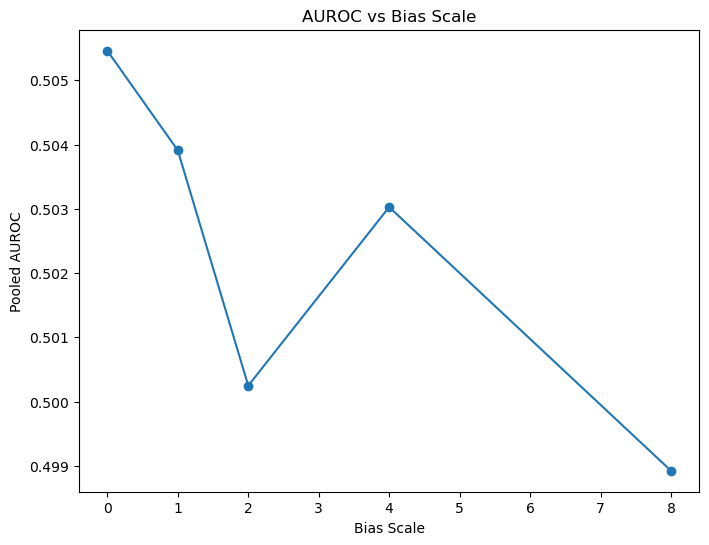

In [56]:
plt.figure(figsize=(8, 6))
plt.plot(auroc_by_bias_scale["bias_scale"], auroc_by_bias_scale["pooled_auroc"], marker="o")
plt.xlabel("Bias Scale")
plt.ylabel("Pooled AUROC")
plt.title("AUROC vs Bias Scale")
plt.show()